In [287]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import plotly.graph_objects as go
from utils import metrics
from scipy import stats
from tqdm import tqdm

In [288]:
def get_component_hists(img):
    r_hist, _ = np.histogram(img[:,0], bins=255, range=(0, 255))
    g_hist, _ = np.histogram(img[:,1], bins=255, range=(0, 255))
    b_hist, _ = np.histogram(img[:,2], bins=255, range=(0, 255))
    r_hist_norm = r_hist / (np.sum(r_hist) + 1e-10)
    g_hist_norm = g_hist / (np.sum(g_hist) + 1e-10)
    b_hist_norm = b_hist / (np.sum(b_hist) + 1e-10)
    return (r_hist_norm, g_hist_norm, b_hist_norm)

def line_difference_horizontal_aux(img, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    
    hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
    hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
    
    hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
    hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
    
    
    difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
    
    while difference < thresh:
        current_x += direction[1]
        hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
        hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
        
        hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
        hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
        
        difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
        
    
    return (current_y, current_x)

def line_difference_horizontal_aux2(img, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    diff_image = 0.45*img_lab[:, :, 1] + 0.45*img_lab[:, :, 2] + 0.1*img_hsv[:, :, 1]
    
    difference = np.abs(diff_image[current_y, current_x] - diff_image[current_y, current_x + direction[1]])
    
    while difference < thresh:
        current_x += direction[1]
        difference = np.abs(diff_image[current_y, current_x] - diff_image[current_y, current_x + direction[1]])
        
    return (current_y, current_x)

def line_difference(diff_image, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    
    current_y = start_coords[0]
    current_x = start_coords[1]
    difference = diff_image[current_y, current_x]
    
    while difference < thresh:
        current_y += direction[0]
        current_x += direction[1]
        if current_x == 0 or current_x >= diff_image.shape[1] - 1 or current_y == 0 or current_y >= diff_image.shape[0] - 1:
            return (current_y, current_x)
        difference = np.abs(diff_image[current_y, current_x])
        #print(difference)
    
    return (current_y, current_x)

def line_difference_horizontal(img, start_coords : tuple, direction : tuple) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    
    hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
    hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
    
    hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
    hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
    
    difference = np.sum([
                  metrics.canberra_distance(hist_a, hist_new_a) * 0.45,
                  metrics.canberra_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
    
    while difference < THRESHOLD_HORIZONTAL:
        current_x += direction[1]
        hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
        hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
        
        hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
        hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
        
        difference = np.sum([
                    metrics.canberra_distance(hist_a, hist_new_a) * 0.45,
                    metrics.canberra_distance(hist_b, hist_new_b) * 0.45,
                    metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
        #print(difference)
    
    return (current_y, current_x)

def line_difference_vertical(img, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    
    hist_l, hist_a, hist_b = get_component_hists(img_lab[current_y])
    hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[current_y + direction[0]])
    
    hist_h, hist_s, hist_v = get_component_hists(img_hsv[current_y])
    hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[current_y + direction[0]])
    
    difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
    
    while difference < thresh and current_y >= 0 and current_y < img.shape[0]:
        current_y += direction[0]
        hist_l, hist_a, hist_b = get_component_hists(img_lab[current_y])
        hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[current_y + direction[0]])
        
        hist_h, hist_s, hist_v = get_component_hists(img_hsv[current_y])
        hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[current_y + direction[0]])
        
        difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
        #print(difference)
    
    return (current_y, current_x)

def get_histogram_peak(img, n_bins=255, n_range=(0, 256)):
    img = img.astype(np.uint8)
    smoothed_img = gaussian_filter1d(img, sigma=5)
    weights = (img != 0).astype(int)
    hist, _ = np.histogram(smoothed_img, bins=n_bins, range=n_range, weights=weights)
    hist = hist.astype(np.float32)
    hist /= np.sum(hist)

    smooth_hist = gaussian_filter1d(hist, sigma=5)
    main_peak = np.argmax(smooth_hist)
    threshold, _ = cv2.threshold(smoothed_img, 0, 1, cv2.THRESH_OTSU)
        
    plt.bar(range(len(smooth_hist)), smooth_hist)
    plt.axvline(threshold)
    plt.show()
        
    return (main_peak, threshold)

def get_histogram_peaks(img) -> list:
    img = img.astype(np.uint8)
    r, g, b = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    
    left_r, right_r = get_histogram_peak(r)
    left_g, right_g = get_histogram_peak(g)
    left_b, right_b = get_histogram_peak(b)
    
    return (left_r, right_r), (left_g, right_g), (left_b, right_b)

def hist_remove_borders(img):
    top_border = img.copy()

    top_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(top_lab)
    
    top_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(top_hsv)
    
    thresh_image = 0.4*a + 0.4*b + 0.2*s
    
    main_peak, threshold = get_histogram_peak(thresh_image)
    
    mask = (thresh_image > threshold) if main_peak < threshold else (thresh_image <= threshold)
    #mask = (s <= mean - std)
    

    top_border[mask] = 0
    return top_border

def compute_vertical_line(point1, point2):
    
    A = point1[1] - point2[1]
    B = point2[0] - point1[0]
    C = point1[0]*point2[1] - point2[0]*point1[1]
    
    if B != 0:
        m = -A / B
        b = -C / B
    else:
        m = 0
        b = -C/A
    
    def line_func(x):
        return m*x + b
    
    return line_func

def compute_horizontal_line(point1, point2):
    
    A = point1[0] - point2[0]
    B = point2[1] - point1[1]
    C = point1[1]*point2[0] - point2[1]*point1[0]
    
    if B != 0:
        m = -A / B
        b = -C / B
    else:
        m = 0
        b = -C/A
    
    def line_func(x):
        return m*x + b
    
    return line_func

In [289]:
def get_borders(img):
    
    middle_x = img.shape[1]//2
    middle_y = img.shape[0]//2
    threshold_vert = 4
    

    #We look from the top
    top_point_left = line_difference_vertical(
        img, start_coords=(0, middle_y), direction=(1,0), thresh=threshold_vert)
    
    bottom_point_left = line_difference_vertical(
        img, start_coords=(img.shape[0] - 1, middle_y), direction=(-1, 0), thresh=threshold_vert)
    
    threshold_hor = 4
    
    left_point = line_difference_horizontal_aux(
        img, start_coords=(top_point_left[0], 0), direction=(0, 1), thresh=threshold_hor
    )
    
    right_point = line_difference_horizontal_aux(
        img, start_coords=(top_point_left[0], img.shape[1] - 1), direction=(0, -1), thresh=threshold_hor
    )
        

    return top_point_left, bottom_point_left, left_point, right_point

In [ ]:
def compute_vertical_side(img, start_coords : tuple, end_coords : tuple, direction : tuple, ray_direction : tuple):
    
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype('float')
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV_FULL).astype(float)
    diff_image = img_hsv[:, :, 1]
    
    
    def_diff_image = np.abs(diff_image[1:diff_image.shape[0], :] - diff_image[:diff_image.shape[0] - 1, :])
    
    points = []
    current_x = start_coords[1]
    current_y = start_coords[0]
    threshold = 3
    
    while current_x <= end_coords[1] and current_y <= end_coords[0]:
        points.append(line_difference(def_diff_image, start_coords=(current_y, current_x), direction=ray_direction, thresh=threshold))
        current_x += direction[1]
        current_y += direction[0]

    
    return np.array(points)

def compute_bottom_side(img, start_coords : tuple, direction : tuple, ray_direction : tuple):
    
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype('float')
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV_FULL).astype(float)
    diff_image = 0.2*img_lab[:,:,1] + 0.2*img_lab[:, :,2] + 0.6*img_hsv[:, :, 1]
    
    def_diff_image = np.abs(diff_image[:, 1:(img.shape[1])] - diff_image[:, :(img.shape[1] - 1)])
    
    """plt.imshow(def_diff_image),
    plt.show()"""
    
    points = []
    current_x = start_coords[1]
    current_y = start_coords[0]
    threshold = 4
    
    while current_x < def_diff_image.shape[1] and current_y < def_diff_image.shape[0]:
        points.append(line_difference(def_diff_image, start_coords=(current_y, current_x), direction=ray_direction, thresh=threshold))
        current_x += direction[1]
        current_y += direction[0]

    
    return np.array(points)

In [291]:
def get_vertical_func(img, top_side : tuple, bottom_side : tuple, ray_direction : tuple, compare_median : int, shift_y : int):
    
    top_side = compute_vertical_side(img, (top_side[0], top_side[1]), (top_side[0]+shift_y, top_side[1]), (1, 0), ray_direction)
    correct_top = top_side[(top_side[:,1] >= compare_median - 20) & (top_side[:, 1] <= compare_median + 20)]
    top_median = int(np.median(correct_top[:, 1])) if len(correct_top) > 0 else compare_median

    bottom_side = compute_vertical_side(img, (bottom_side[0] - shift_y, bottom_side[1]), (bottom_side[0], bottom_side[1]), (1, 0), ray_direction)
    correct_bottom = bottom_side[(bottom_side[:,1] >= compare_median - 20) & (bottom_side[:, 1] <= compare_median + 20)]
    bottom_median = int(np.median(correct_bottom[:, 1])) if len(correct_bottom) > 0 else compare_median
    
    try:
        candidates = np.where(correct_bottom[: , 1] == bottom_median)
        max_side = (np.argmax(correct_bottom[candidates[0]][:, 0]))

        bottom_point = correct_bottom[max_side]

        candidates = np.where(correct_top[: , 1] == top_median)
        max_side = (np.argmax(correct_top[candidates[0]][:, 0]))

        top_point = correct_top[max_side]

        line_func = compute_vertical_line(top_point, bottom_point)
    except:
        line_func = compute_vertical_line((0, compare_median), (10, compare_median))

    return line_func
    
    

Correct bottom: 395
Correct left: 10
Correct right: 515


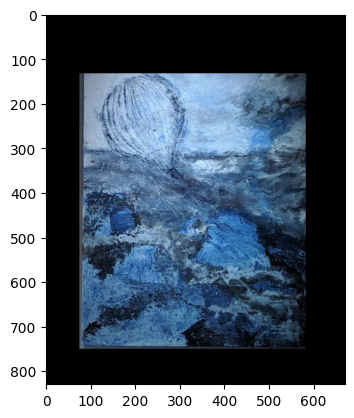

In [292]:
img = cv2.imread("data/qsd2_w1/00028.jpg", cv2.IMREAD_UNCHANGED)
middle_y = img.shape[0] // 2
shift_y = middle_y // 4

# Get points by whole row/column aware methods
top_point, bottom_point, left_point, right_point = get_borders(img)

#Combine row aware with ray throw to get a corrected bottom side
bottom_side = compute_bottom_side(img, (img.shape[0] - 1, 0), (0, 1), (-1, 0))
bottom_median= int(np.median(bottom_side[:, 0]))

correct_values = bottom_side[(bottom_side[:,0] <= bottom_point[0] +10) & (bottom_side[:, 0] >= bottom_median - 10)]
corrected_median = int(np.median(correct_values[:, 0])) if len(correct_values) > 0 else bottom_point[0]

print(f"Correct bottom: {len(correct_values)}")

border_image = img.copy()

left_side = compute_vertical_side(img, (top_point[0], 0), (corrected_median, 0), (1, 0), (0, 1))
left_median = int(np.median(left_side[:, 1]))
correct_left_values = left_side[(left_side[:,1] >= left_point[1] - 10) & (left_side[:, 1] <= left_median - 10)]
corrected_left_median = int(np.median(correct_left_values[:, 1])) if len(correct_left_values) > 0 else left_point[1]
print(f"Correct left: {len(correct_left_values)}")

right_side = compute_vertical_side(img, (top_point[0], img.shape[1] - 1), (corrected_median, img.shape[1] - 1), (1, 0), (0, -1))
right_median = int(np.median(right_side[:, 1]))
correct_right_values = right_side[(right_side[:,1] <= right_point[1] +10) & (right_side[:, 1] >= right_median - 10)]
corrected_right_median = int(np.median(correct_right_values[:, 1])) if len(correct_right_values) > 0 else right_point[1]

print(f"Correct right: {len(correct_right_values)}")

left_line_func = get_vertical_func(img, (top_point[0], 0), (corrected_median, 0), (0, 1), corrected_left_median, shift_y)
right_line_func = get_vertical_func(img, (top_point[0], img.shape[1] - 1), (corrected_median, img.shape[1] - 1), (0, -1), corrected_right_median, shift_y)

y = np.array([left_line_func(x) for x in range(img.shape[0])])

W = img.shape[1]
cols = np.arange(W)
mask_left = cols < y[:, None]

y = np.array([right_line_func(x) for x in range(img.shape[0])])

W = img.shape[1]
cols = np.arange(W)
mask_right = cols > y[:, None]

mask = mask_left | mask_right

border_image[mask] = 0
border_image[range(img.shape[0] - 1, corrected_median, -1), :, :] = 0
border_image[range(top_point[0]), :, :] = 0
#border_image[:, range(img.shape[1] - 1, rt_median, -1), :] = 0

plt.imshow(border_image)
plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

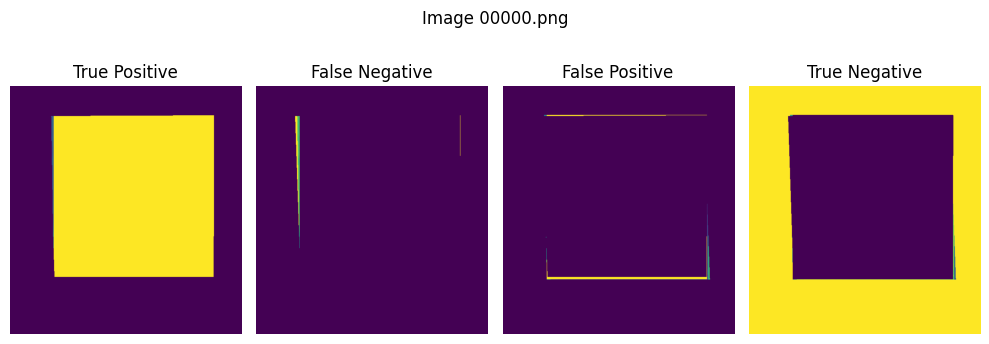

  3%|▎         | 1/30 [00:00<00:22,  1.31it/s]

Precision: 0.978276797437903
Recall: 0.9894178709279421
F_score: 0.9838157938427198


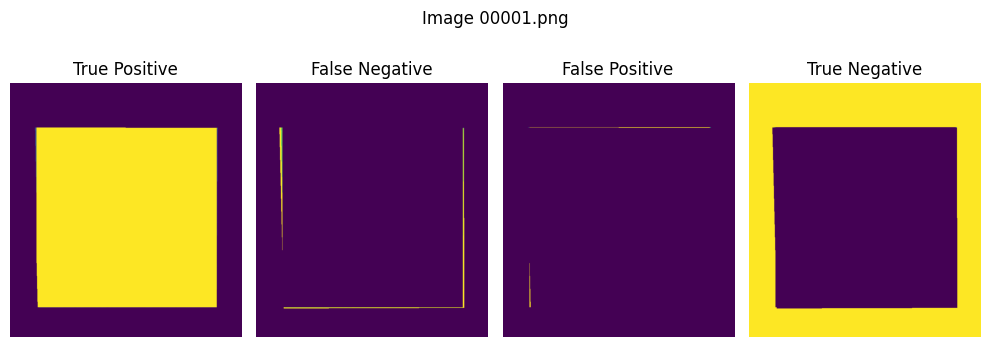

  7%|▋         | 2/30 [00:01<00:24,  1.16it/s]

Precision: 0.9964806421423574
Recall: 0.982385669755279
F_score: 0.9893829584581141


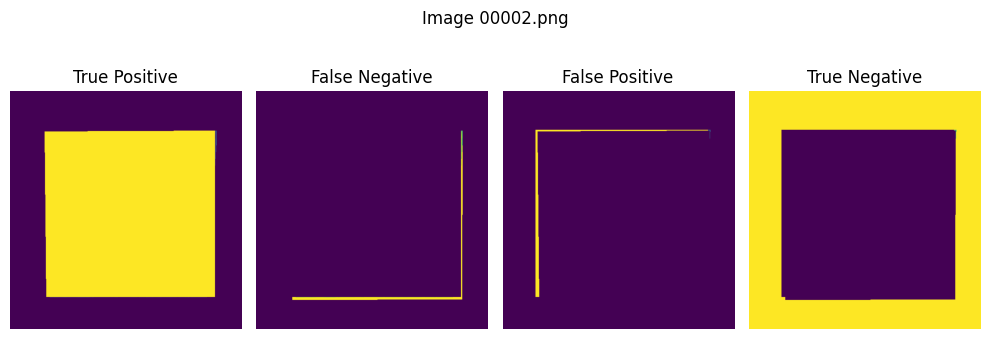

 10%|█         | 3/30 [00:02<00:19,  1.39it/s]

Precision: 0.9754836633830061
Recall: 0.9758508835633019
F_score: 0.9756672389197092


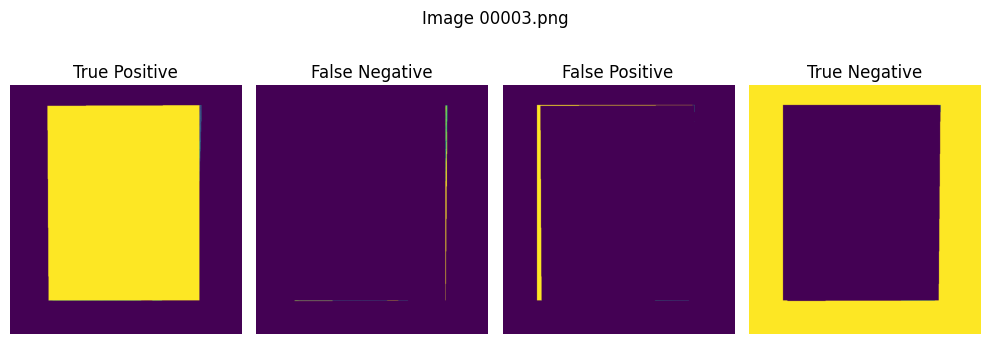

 13%|█▎        | 4/30 [00:03<00:20,  1.26it/s]

Precision: 0.9712763102976625
Recall: 0.9925554886211728
F_score: 0.9818006137637758


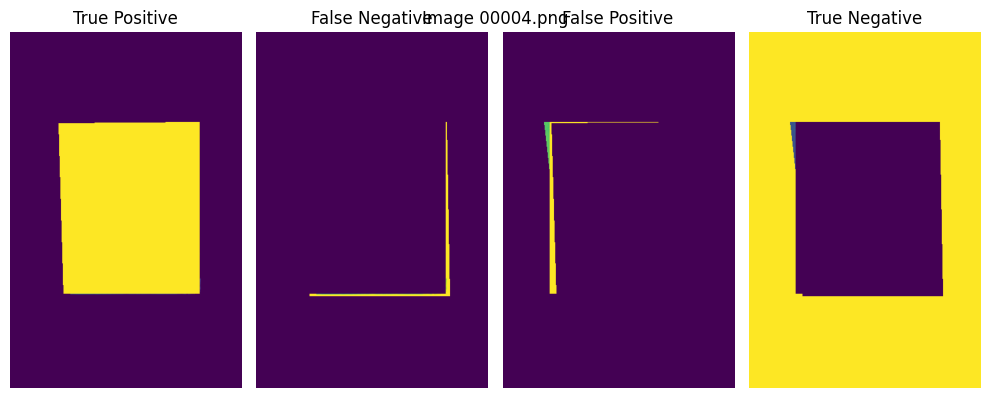

 17%|█▋        | 5/30 [00:03<00:17,  1.44it/s]

Precision: 0.9623010446042499
Recall: 0.9672558900017945
F_score: 0.9647721056112594


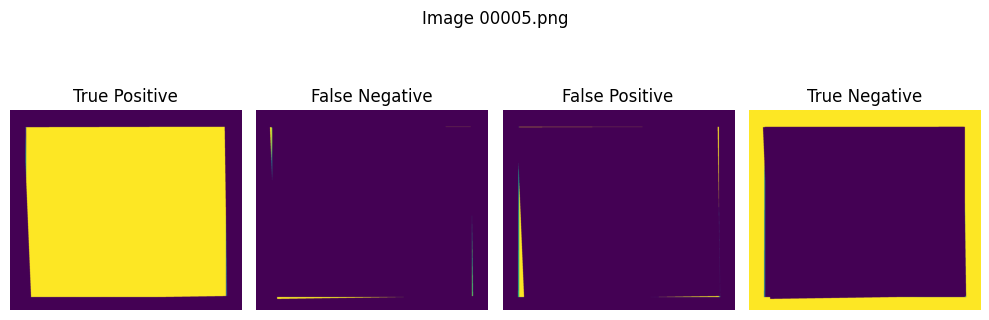

 20%|██        | 6/30 [00:06<00:30,  1.25s/it]

Precision: 0.9861349235543342
Recall: 0.9939167545888088
F_score: 0.9900105473256748


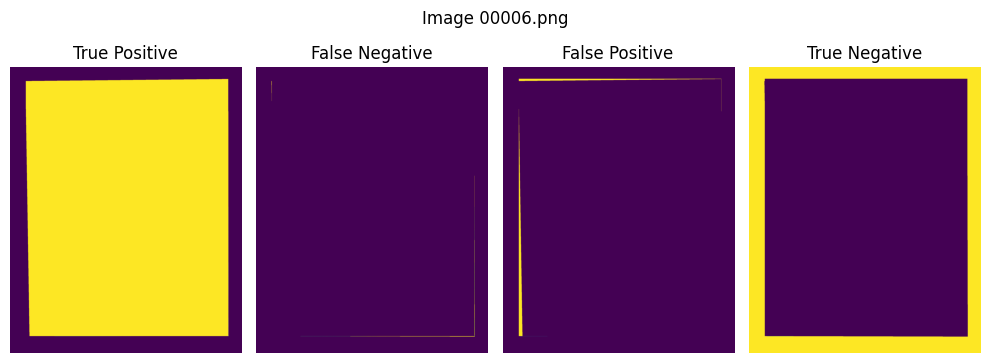

 23%|██▎       | 7/30 [00:08<00:40,  1.77s/it]

Precision: 0.9867802494531518
Recall: 0.9983403292390367
F_score: 0.9925266300696527


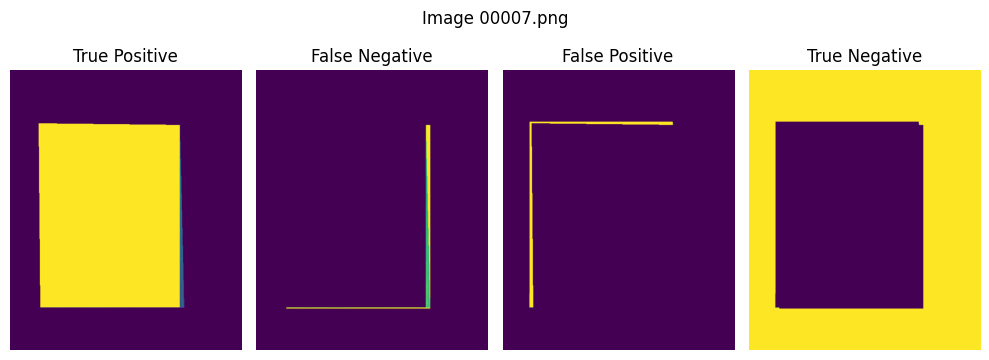

 27%|██▋       | 8/30 [00:09<00:31,  1.45s/it]

Precision: 0.9668136958576847
Recall: 0.9678076388281277
F_score: 0.9673104120157756


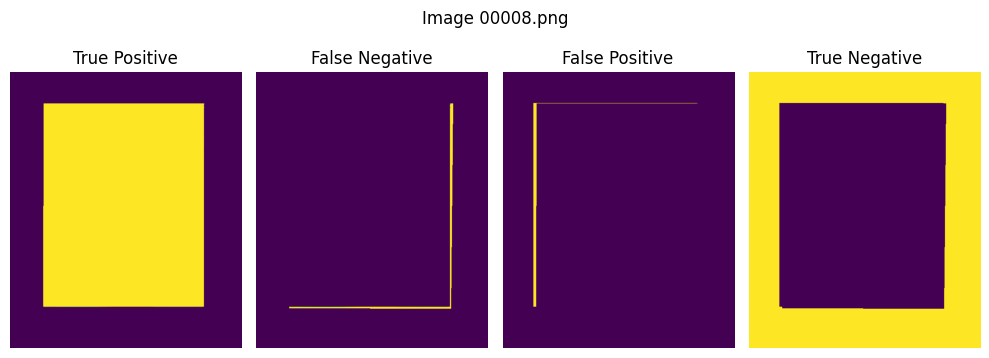

 30%|███       | 9/30 [00:10<00:25,  1.20s/it]

Precision: 0.9794756452110666
Recall: 0.9778472030025286
F_score: 0.978660746695805


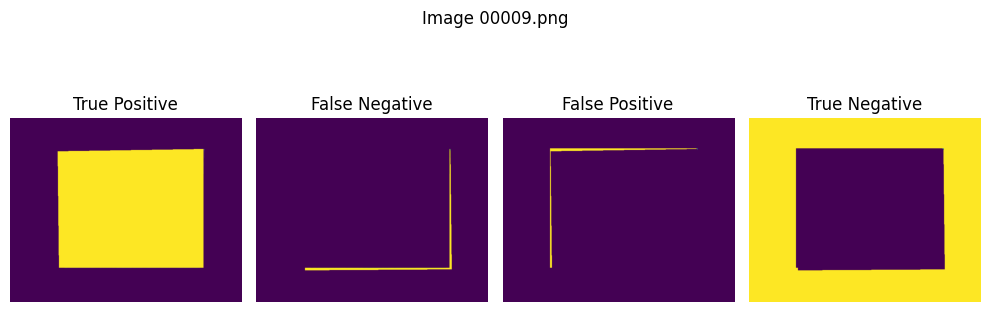

 33%|███▎      | 10/30 [00:10<00:20,  1.03s/it]

Precision: 0.9762529612172238
Recall: 0.9716439162122275
F_score: 0.9739429858347235


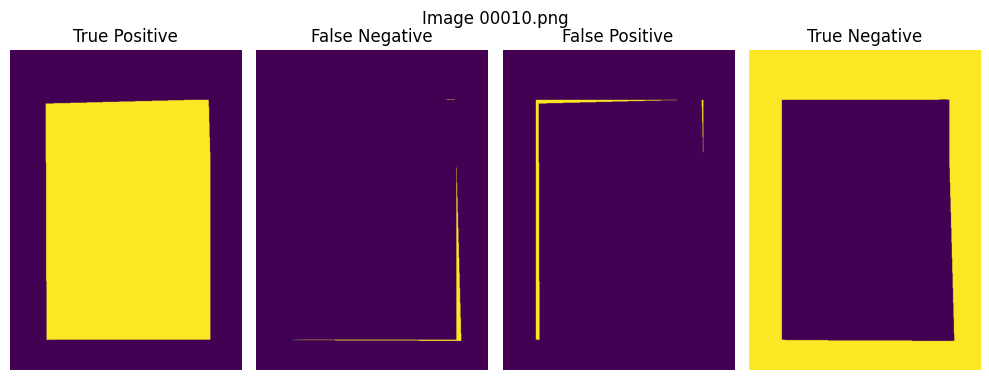

 37%|███▋      | 11/30 [00:11<00:17,  1.09it/s]

Precision: 0.9724675713779471
Recall: 0.9853525662795173
F_score: 0.9788676688425384


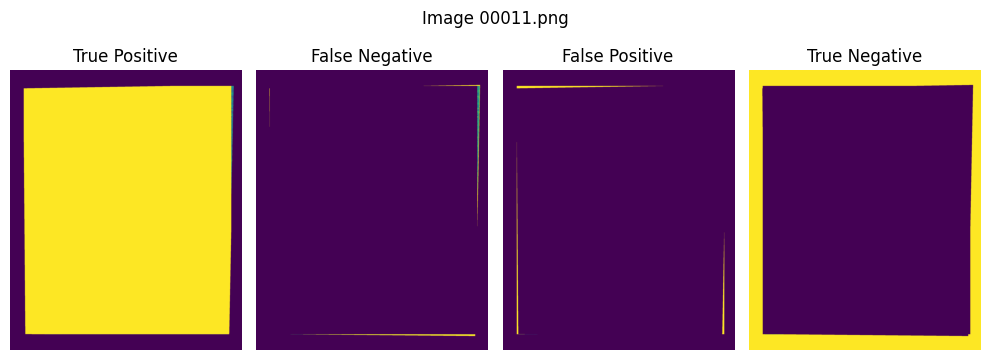

 40%|████      | 12/30 [00:14<00:27,  1.54s/it]

Precision: 0.9913185090947523
Recall: 0.9932776964928433
F_score: 0.9922971357418477


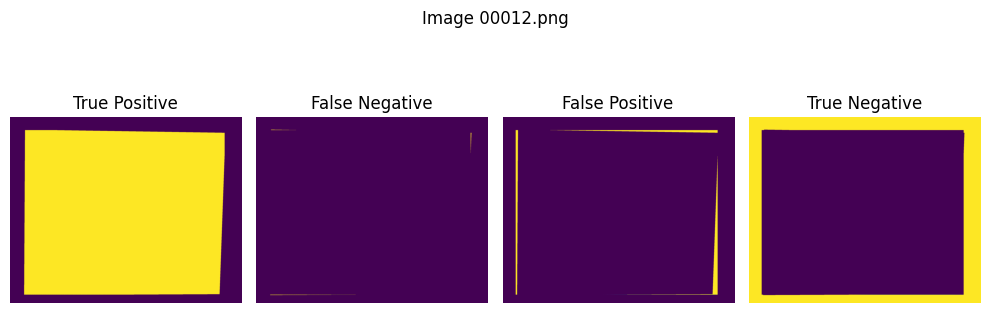

 43%|████▎     | 13/30 [00:16<00:30,  1.78s/it]

Precision: 0.9722485345985403
Recall: 0.9988824926762335
F_score: 0.9853855743758492


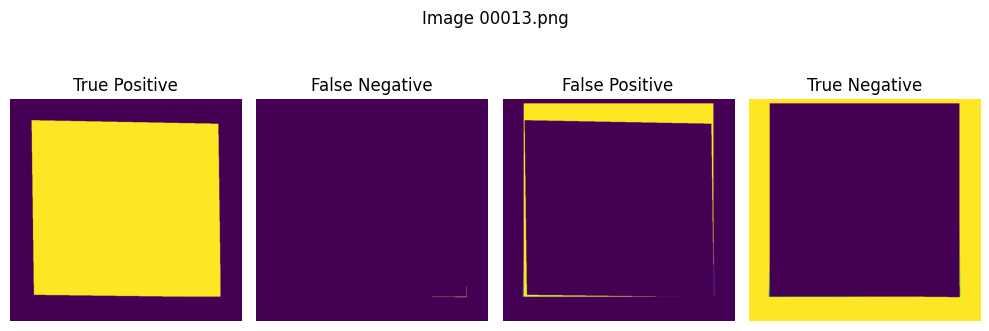

 47%|████▋     | 14/30 [00:17<00:22,  1.43s/it]

Precision: 0.8856577251413874
Recall: 0.9995409272996809
F_score: 0.9391595338896218


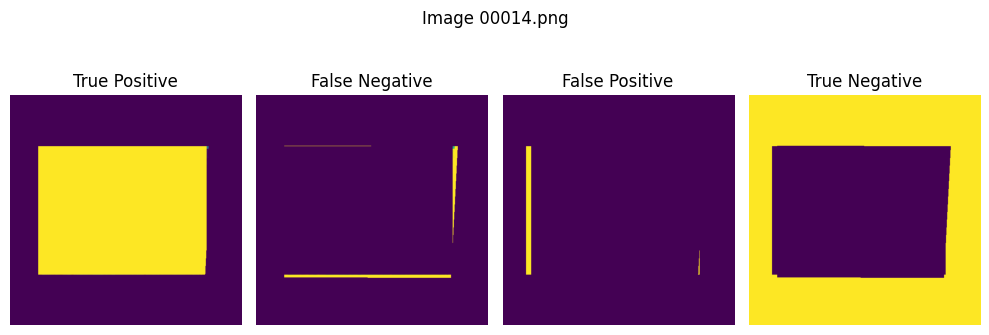

 50%|█████     | 15/30 [00:18<00:18,  1.26s/it]

Precision: 0.9693720518914452
Recall: 0.9650409788223827
F_score: 0.9672016668076042


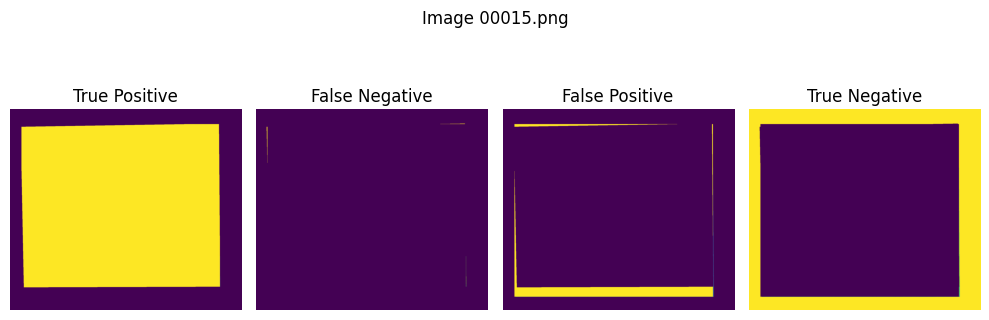

 53%|█████▎    | 16/30 [00:19<00:18,  1.31s/it]

Precision: 0.9308951938642099
Recall: 0.9991148772848549
F_score: 0.9637993617608093


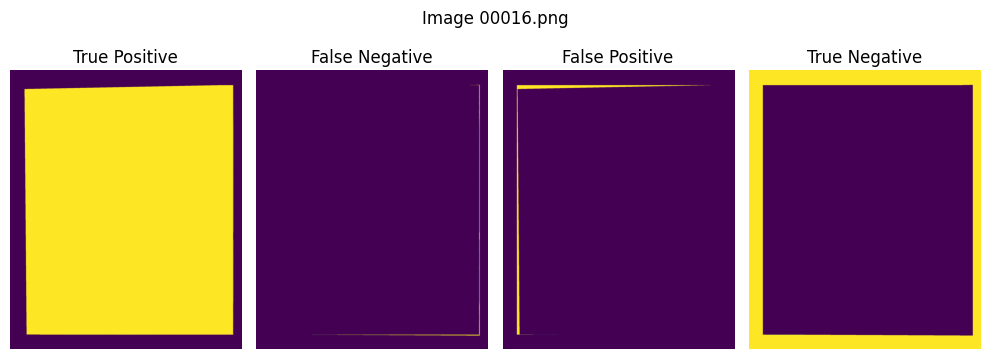

 57%|█████▋    | 17/30 [00:22<00:21,  1.66s/it]

Precision: 0.9846693244923775
Recall: 0.9957204778500837
F_score: 0.990164066839931


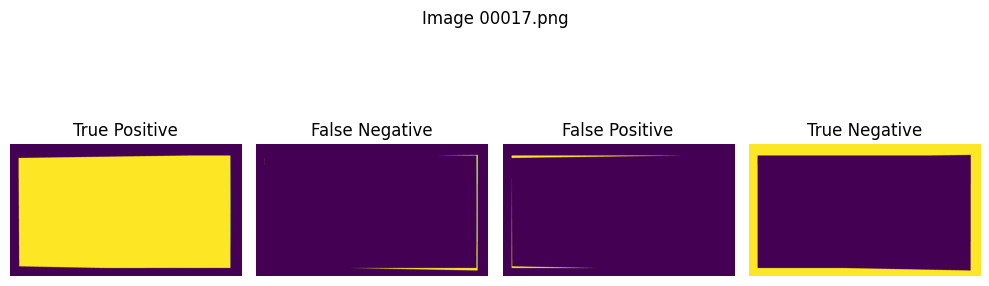

 60%|██████    | 18/30 [00:25<00:24,  2.03s/it]

Precision: 0.9868969836475391
Recall: 0.9870181324960778
F_score: 0.9869575543540591


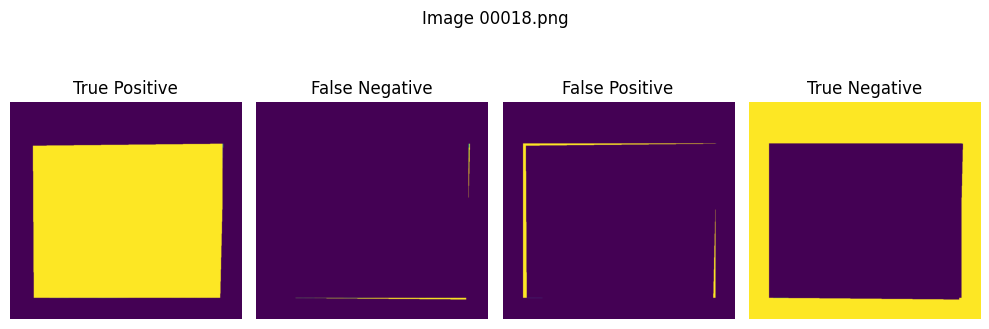

 63%|██████▎   | 19/30 [00:25<00:17,  1.63s/it]

Precision: 0.9710520287527432
Recall: 0.9932613476773222
F_score: 0.9820311344584345


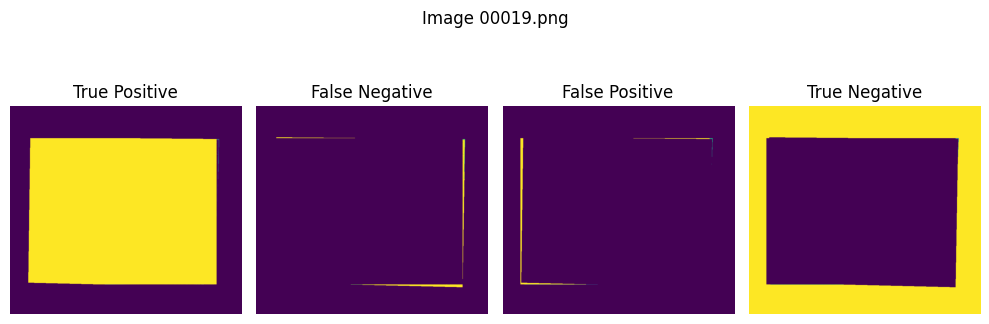

 67%|██████▋   | 20/30 [00:26<00:13,  1.35s/it]

Precision: 0.9863340924009323
Recall: 0.9859437505876651
F_score: 0.9861388828672027


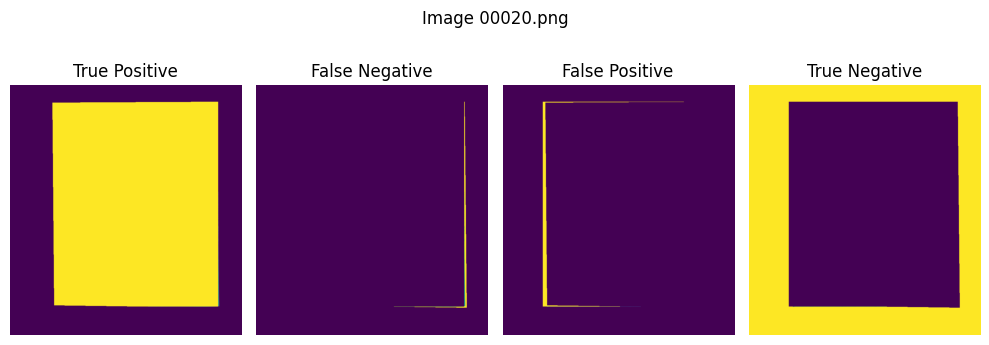

 70%|███████   | 21/30 [00:27<00:10,  1.22s/it]

Precision: 0.9756687993491987
Recall: 0.9896495141780686
F_score: 0.9826094293515953


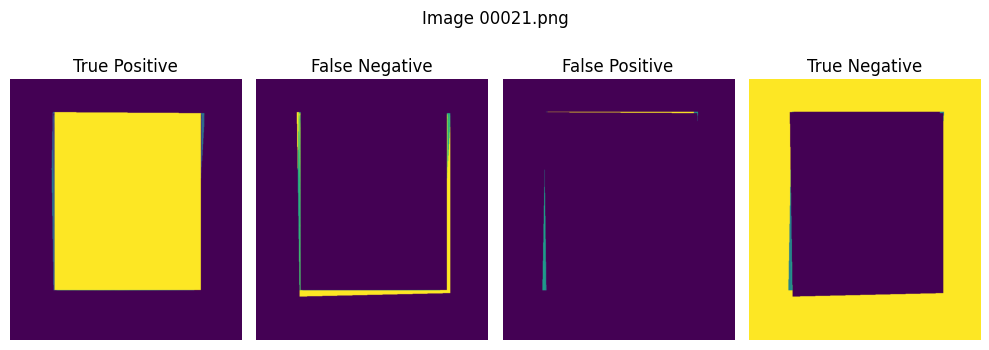

 73%|███████▎  | 22/30 [00:28<00:08,  1.12s/it]

Precision: 0.9899803868122327
Recall: 0.9423857701529832
F_score: 0.965596945381804


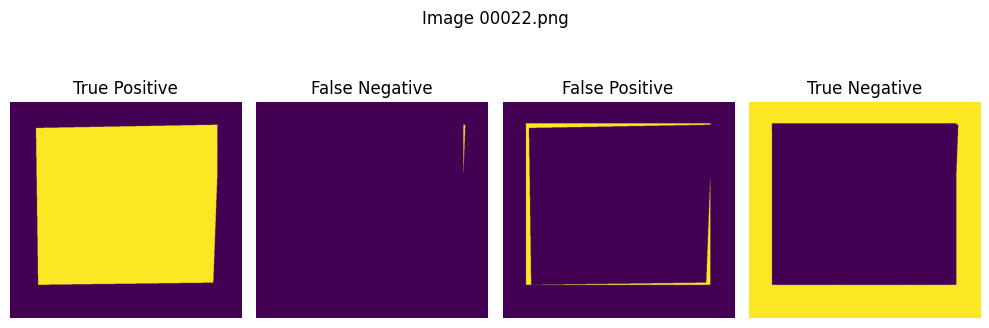

 77%|███████▋  | 23/30 [00:29<00:07,  1.04s/it]

Precision: 0.94541533945118
Recall: 0.9983547552354275
F_score: 0.9711641334473552


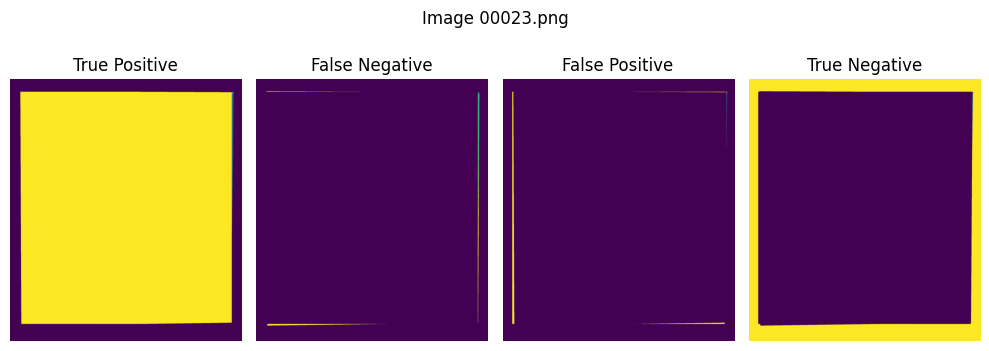

 80%|████████  | 24/30 [00:31<00:09,  1.54s/it]

Precision: 0.9907261887966461
Recall: 0.9938859917574426
F_score: 0.9923035748347707


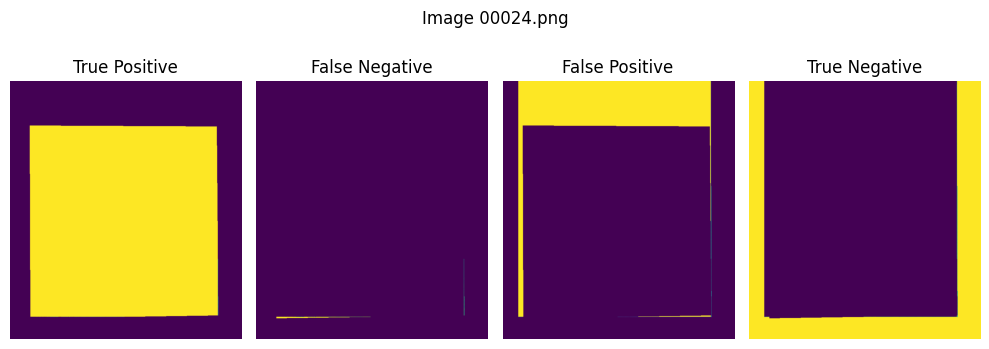

 83%|████████▎ | 25/30 [00:32<00:06,  1.31s/it]

Precision: 0.7837221403224671
Recall: 0.9974072441215857
F_score: 0.8777466106204216


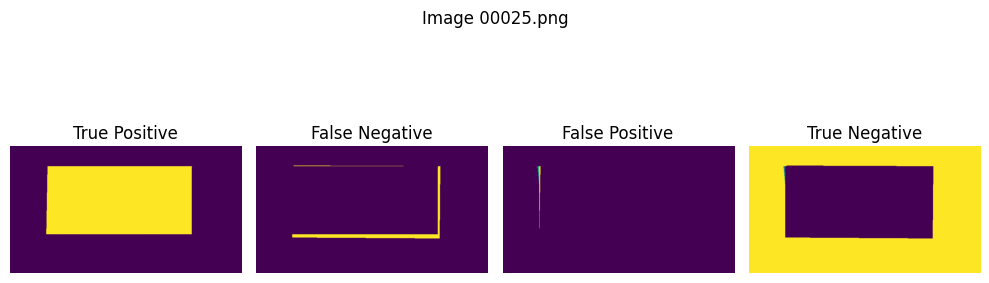

 87%|████████▋ | 26/30 [00:33<00:04,  1.09s/it]

Precision: 0.9944177297291119
Recall: 0.9288540135785256
F_score: 0.960518348638563


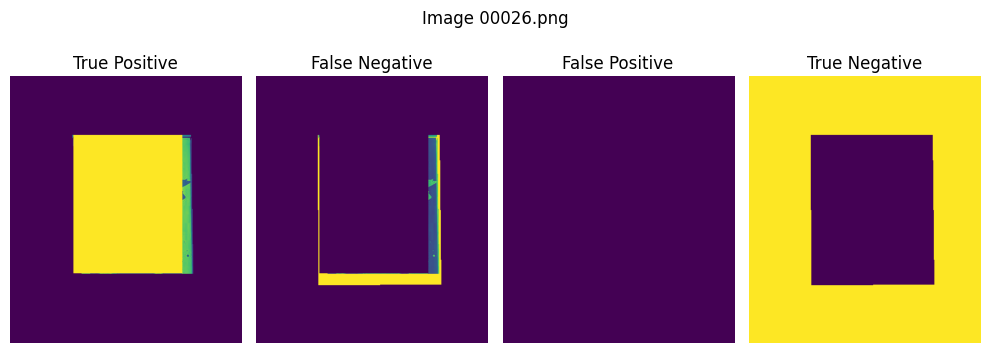

 90%|█████████ | 27/30 [00:33<00:02,  1.09it/s]

Precision: 1.0
Recall: 0.8706311934005844
F_score: 0.9308421632998439


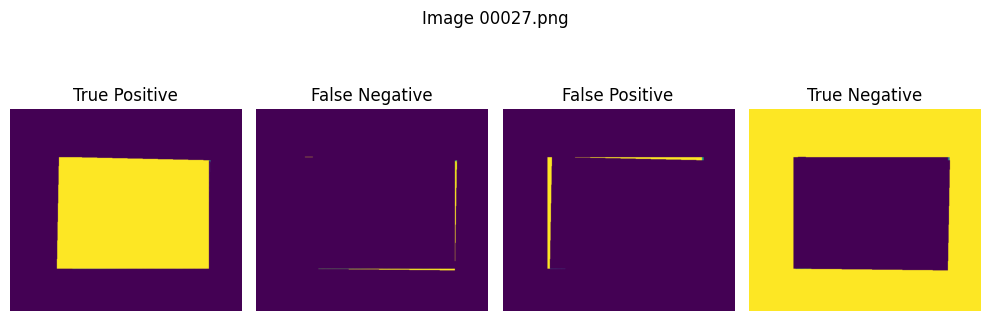

 93%|█████████▎| 28/30 [00:34<00:01,  1.15it/s]

Precision: 0.9655787688832427
Recall: 0.9858106267114466
F_score: 0.9755898166106105


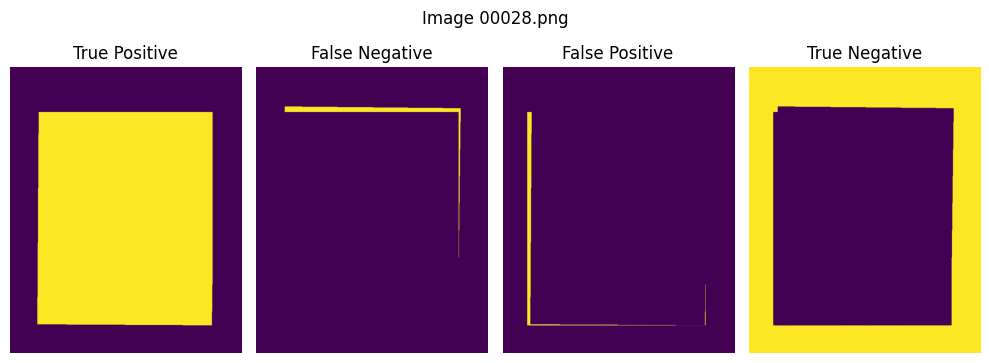

 97%|█████████▋| 29/30 [00:35<00:00,  1.22it/s]

Precision: 0.9756384537203987
Recall: 0.9742259959990719
F_score: 0.9749317132762724


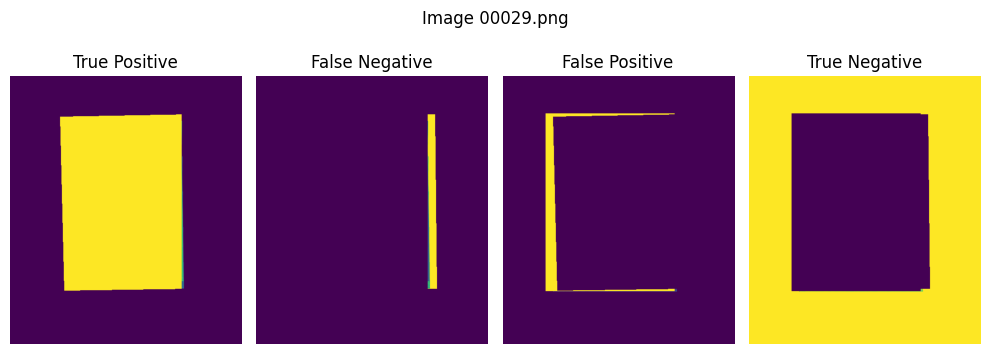

100%|██████████| 30/30 [00:35<00:00,  1.19s/it]

Precision: 0.9076956197641294
Recall: 0.939089967344633
F_score: 0.923125950162575
Average F_score : 0.9708107099366307
Average Precision : 0.9653010458416375
Average Recall : 0.9780156654895552


In [293]:
score = 0
precision = 0
recall = 0

for i in tqdm(range(30)):
    img = cv2.imread(f"data/qsd2_w1/{i:05d}.jpg", cv2.IMREAD_UNCHANGED)
    correct_img = cv2.imread(f"data/qsd2_w1/{i:05d}.png", cv2.IMREAD_UNCHANGED)
    middle_y = img.shape[0] // 2
    shift_y = middle_y // 4

    # Get points by whole row/column aware methods
    top_point, bottom_point, left_point, right_point = get_borders(img)

    #Combine row aware with ray throw to get a corrected bottom side
    bottom_side = compute_bottom_side(img, (img.shape[0] - 1, 0), (0, 1), (-1, 0))
    bottom_median= int(np.median(bottom_side[:, 0]))

    correct_values = bottom_side[(bottom_side[:,0] <= bottom_point[0] +10) & (bottom_side[:, 0] >= bottom_median - 10)]
    corrected_median = int(np.median(correct_values[:, 0])) if len(correct_values) > 0 else bottom_point[0]

    border_image = img.copy()

    left_side = compute_vertical_side(img, (top_point[0], 0), (corrected_median, 0), (1, 0), (0, 1))
    left_median = int(np.median(left_side[:, 1]))
    correct_left_values = left_side[(left_side[:,1] >= left_point[1] - 10) & (left_side[:, 1] <= left_median - 10)]
    corrected_left_median = int(np.median(correct_left_values[:, 1])) if len(correct_left_values) > 0 else left_point[1]

    right_side = compute_vertical_side(img, (top_point[0], img.shape[1] - 1), (corrected_median, img.shape[1] - 1), (1, 0), (0, -1))
    right_median = int(np.median(right_side[:, 1]))
    correct_right_values = right_side[(right_side[:,1] <= right_point[1] +10) & (right_side[:, 1] >= right_median - 10)]
    corrected_right_median = int(np.median(correct_right_values[:, 1])) if len(correct_right_values) > 0 else right_point[1]
    
    left_line_func = get_vertical_func(img, (top_point[0], 0), (corrected_median, 0), (0, 1), corrected_left_median, shift_y)
    right_line_func = get_vertical_func(img, (top_point[0], img.shape[1] - 1), (corrected_median, img.shape[1] - 1), (0, -1), corrected_right_median, shift_y)

    y = np.array([left_line_func(x) for x in range(img.shape[0])])

    W = img.shape[1]
    cols = np.arange(W)
    mask_left = cols < y[:, None]

    y = np.array([right_line_func(x) for x in range(img.shape[0])])

    W = img.shape[1]
    cols = np.arange(W)
    mask_right = cols > y[:, None]

    mask = mask_left | mask_right

    border_image[mask] = 0
    border_image[range(img.shape[0] - 1, corrected_median, -1), :, :] = 0
    border_image[range(top_point[0]), :, :] = 0
    
    """f, ax = plt.subplots(1, 2)
    f.suptitle(f"Image f{i:05f}.png")
    plt.axis('off')
    ax[0].imshow(border_image)
    ax[0].axis('off')"""
    
    border_image[top_point[0]:corrected_median, corrected_left_median:corrected_right_median, :] = 255
    
    """ax[1].imshow(border_image)
    ax[1].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 1.2])
    plt.show()"""
    
    result = border_image[:, :, 0]
    
    
    TP = np.sum(correct_img & result)
    FN = np.sum(correct_img & (255 - result))
    FP = np.sum((255 - correct_img) & result)
    TN = np.sum((255 - correct_img) & (255 - result))
    
    f, ax = plt.subplots(1, 4, figsize=(10, 8))
    f.suptitle(f"Image {i:05d}.png")
    plt.axis('off')
    ax[0].imshow(correct_img & result)
    ax[0].axis('off')
    ax[0].set_title("True Positive")
    
    ax[1].imshow(correct_img & (255 - result))
    ax[1].axis('off')
    ax[1].set_title("False Negative")
    
    ax[2].imshow((255 - correct_img) & result)
    ax[2].axis('off')
    ax[2].set_title("False Positive")
    
    ax[3].imshow((255 - correct_img) & (255 - result))
    ax[3].axis('off')
    ax[3].set_title("True Negative")
    
    plt.tight_layout(rect=[0, 0, 1, 1.5])
    
    plt.show()
    
    
    P = TP / (TP + FP)
    R = TP / (TP + FN)
    F_score = 2*(P*R/(P + R))
    
    score = score + F_score
    precision += P
    recall += R
    
    print(f"Precision: {P}\nRecall: {R}\nF_score: {F_score}")
    
print(f"Average F_score : {score/30}")
print(f"Average Precision : {precision/30}")
print(f"Average Recall : {recall/30}")
    